# 04 — LDA Topic Modeling on BIS Central Bank Speeches

This notebook implements a **Latent Dirichlet Allocation (LDA)** topic model on the preprocessed BIS central bank speeches dataset.

The objective is to extract interpretable monetary-policy topics and compare this probabilistic topic model with the NMF baseline and, later, with BERTopic.

## Why LDA here?

LDA is a classical probabilistic topic model. Its main assumptions are:

- each document is a mixture of latent topics;
- each topic is a probability distribution over words;
- the number of topics is fixed in advance;
- word order is ignored, as in a bag-of-words representation.

In the course, LDA is implemented with:

> `CountVectorizer + LatentDirichletAllocation`

This is why we use **raw word counts**, not TF-IDF, in this notebook.


## 1. Imports and general settings

We import the libraries needed for data manipulation, count-based vectorization, LDA modeling, evaluation metrics, and visualizations.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load the preprocessed dataset

If you are running this notebook on Google Colab and the CSV file is on your local computer, upload it using the following cell.

The file needed here is:

`bis_speeches_preprocessed.csv`

It was created in the preprocessing notebook.


In [2]:
# Check the current working directory
print("Current working directory:", os.getcwd())

# List available CSV files in the current folder
csv_files = [f for f in os.listdir(".") if f.endswith(".csv")]
print("CSV files in current directory:", csv_files)



Current working directory: /content
CSV files in current directory: []


In [3]:
from google.colab import drive
drive.mount('/content/drive')


import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Data/bis_speeches_preprocessed_CB.csv")
df.head()

Mounted at /content/drive


,description,raw_text_stripped,clean_text,bertopic_text,central_bank,year,month,macro_period,n_words_raw,n_characters_raw,n_words_clean
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens...","Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",tietmeyer consider european monetary integration implication international monetary lecture deliver honour professor xenophon zolotas honorary greece president deutsche bundesb...,"Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Hono...",bank of greece,1997,10,Pre-GFC,5070,31212,2078
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 September 1999.","Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",garganas integrate greece euro area challenge nicholas garganas greece athens summit september adoption euro common currency group european union member state january historic ...,"Mr Garganas gives a speech on integrating Greece into the euro area and the challenges ahead Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at t...",bank of greece,1999,9,Pre-GFC,2307,14497,1096
2,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October 2001.","Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",lucas papademos completion changeover euro lucas papademos greece euro information athens october welcome session euro information presence attest importance attach successful ...,"Lucas Papademos: The completion of the changeover to the euro Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 Octob...",bank of greece,2001,10,Pre-GFC,2975,18231,1213
3,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association, New York, 23 April 2002.","Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",nicholas garganas greek economy euro area nicholas garganas greece hellenic american bankers association york april great pleasure able transformation greek economy beginning g...,"Nicholas Garganas: The Greek economy within the euro area Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association...",bank of greece,2002,5,Pre-GFC,2129,13387,1008
4,"Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset Management, Athens, 22 October 2002.","Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset...",nicholas garganas european financial marketplace nicholas garganas greece economist private banking asset management athens october lady gentleman let start thank economist inv...,"Nicholas C Garganas: The European financial marketplace Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset...",bank of greece,2002,10,Pre-GFC,2001,13166,982


In [4]:
# from google.colab import files
# uploaded = files.upload()


In [5]:
# DATA_PATH = "bis_speeches_preprocessed.csv"
# df = pd.read_csv(DATA_PATH)

# print("Shape:", df.shape)
# df.head()


## 3. Basic checks

Before fitting the model, I check that the main variables are available and that the cleaned text column contains no missing values.

For LDA, I use `clean_text`, because LDA is a bag-of-words model and therefore benefits from stronger preprocessing.


In [6]:
required_columns = ["clean_text", "central_bank", "year", "month", "macro_period", "description", "raw_text_stripped"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

print("Number of speeches:", len(df))
print("Missing clean_text:", df["clean_text"].isna().sum())
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())
print("Number of central banks:", df["central_bank"].nunique())

df[["description", "clean_text", "year", "macro_period", "central_bank"]].head()


Number of speeches: 18922
Missing clean_text: 0
Minimum year: 1997
Maximum year: 2025
Number of central banks: 118


,description,clean_text,year,macro_period,central_bank
0,"Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens...",tietmeyer consider european monetary integration implication international monetary lecture deliver honour professor xenophon zolotas honorary greece president deutsche bundesb...,1997,Pre-GFC,bank of greece
1,"Speech given by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, at the 'Athens Summit 1999' on 18 September 1999.",garganas integrate greece euro area challenge nicholas garganas greece athens summit september adoption euro common currency group european union member state january historic ...,1999,Pre-GFC,bank of greece
2,"Speech by Mr Lucas Papademos, Governor of the Bank of Greece, at the Euro Information Conference, Athens, 17 October 2001.",lucas papademos completion changeover euro lucas papademos greece euro information athens october welcome session euro information presence attest importance attach successful ...,2001,Pre-GFC,bank of greece
3,"Address by Mr Nicholas C Garganas, Deputy Governor of the Bank of Greece, to the Hellenic American Bankers Association, New York, 23 April 2002.",nicholas garganas greek economy euro area nicholas garganas greece hellenic american bankers association york april great pleasure able transformation greek economy beginning g...,2002,Pre-GFC,bank of greece
4,"Speech by Mr Nicholas C Garganas, Governor of the Bank of Greece, at The Economist Conference: Private Banking and Asset Management, Athens, 22 October 2002.",nicholas garganas european financial marketplace nicholas garganas greece economist private banking asset management athens october lady gentleman let start thank economist inv...,2002,Pre-GFC,bank of greece


In [7]:
df["clean_text"] = df["clean_text"].fillna("").astype(str)

df = df.reset_index(drop=True)
df["doc_id"] = df.index

df[["doc_id", "year", "macro_period", "central_bank", "clean_text"]].head()


,doc_id,year,macro_period,central_bank,clean_text
0,0,1997,Pre-GFC,bank of greece,tietmeyer consider european monetary integration implication international monetary lecture deliver honour professor xenophon zolotas honorary greece president deutsche bundesb...
1,1,1999,Pre-GFC,bank of greece,garganas integrate greece euro area challenge nicholas garganas greece athens summit september adoption euro common currency group european union member state january historic ...
2,2,2001,Pre-GFC,bank of greece,lucas papademos completion changeover euro lucas papademos greece euro information athens october welcome session euro information presence attest importance attach successful ...
3,3,2002,Pre-GFC,bank of greece,nicholas garganas greek economy euro area nicholas garganas greece hellenic american bankers association york april great pleasure able transformation greek economy beginning g...
4,4,2002,Pre-GFC,bank of greece,nicholas garganas european financial marketplace nicholas garganas greece economist private banking asset management athens october lady gentleman let start thank economist inv...


## 4. CountVectorizer representation

LDA is a generative probabilistic model based on word counts. Therefore, I use `CountVectorizer` rather than `TfidfVectorizer`.

Each row of the resulting matrix corresponds to one speech, and each column corresponds to one word or bigram.

### Parameter choices

- `min_df=20`: remove terms that appear in fewer than 20 speeches.
- `max_df=0.85`: remove terms that appear in more than 85% of speeches.
- `max_features=10000`: keep a maximum of 10,000 terms.
- `ngram_range=(1, 2)`: include unigrams and bigrams, because many monetary-policy concepts are multi-word expressions.


In [8]:
vectorizer = CountVectorizer(
    min_df=20,          # Keep terms appearing in at least 20 speeches
    max_df=0.85,        # Remove terms appearing in more than 85% of speeches
    max_features=10000, # Keep at most 10,000 vocabulary terms
    ngram_range=(1, 2)  # Use unigrams and bigrams
)

# Transform cleaned texts into a sparse document-term count matrix
X_counts = vectorizer.fit_transform(df["clean_text"])

# Get the vocabulary terms corresponding to the columns of X_counts
feature_names = np.array(vectorizer.get_feature_names_out())

print("Document-term matrix shape:", X_counts.shape)
print("Number of documents:", X_counts.shape[0])
print("Vocabulary size:", X_counts.shape[1])
print("Matrix type:", type(X_counts))
print("Sparsity: {:.2%}".format(1 - X_counts.nnz / (X_counts.shape[0] * X_counts.shape[1])))
#93.15% sparsity : Cela veut dire que 93.15% des cases de la matrice sont nulles.
#C’est normal : chaque discours ne contient qu’une petite partie des 10 000 termes possibles.


Document-term matrix shape: (18922, 10000)
Number of documents: 18922
Vocabulary size: 10000
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Sparsity: 93.81%


### Inspect the vocabulary

This quick check helps verify that the vectorizer kept relevant monetary and financial terms.


In [9]:
feature_names[:100]


array(['10th', '19th', '19th century', '1st', '20th', '20th century',
       '21st', '21st century', '2nd', '3rd', '4th', 'aaa', 'abandon',
       'abate', 'ability', 'able', 'able meet', 'able provide', 'abolish',
       'abrupt', 'abs', 'absence', 'absent', 'absolute', 'absorb',
       'absorb loss', 'absorb shock', 'absorption', 'abstract',
       'abundance', 'abundant', 'abuse', 'academia', 'academic',
       'academic research', 'academy', 'accelerate', 'accelerated',
       'acceleration', 'accelerator', 'accentuate', 'accept',
       'acceptable', 'acceptance', 'access', 'access capital',
       'access credit', 'access finance', 'access financial',
       'access financing', 'access liquidity', 'access market',
       'accessibility', 'accessible', 'accession', 'accession country',
       'accident', 'accommodate', 'accommodation', 'accommodative',
       'accommodative financial', 'accommodative monetary',
       'accommodative policy', 'accommodative stance', 'accompany',
  

## 5. Helper functions for topic extraction and evaluation

LDA returns a topic-word matrix. Each topic is represented by a distribution over the vocabulary. To interpret the model, I inspect the highest-probability words in each topic.

I also compute a simple **UMass coherence** score. Topic modeling is unsupervised, so there is no accuracy score. Perplexity can be computed for LDA, but fitting metrics such as perplexity are not always aligned with human topic coherence. Therefore, I report both:

- **perplexity**: model fitting metric;
- **UMass coherence**: approximate coherence based on word co-occurrence;
- **human interpretation**: final criterion for selecting the model.


In [10]:
def get_top_words_lda(model, feature_names, n_top_words=15):
    """Return top words for each LDA topic in a long-format dataframe."""
    #En LDA, un topic est une distribution de mots.Les top words sont les mots qui ont le plus grand poids/probabilité dans ce topic.
    rows = []
    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[::-1][:n_top_words]
        top_terms = feature_names[top_indices]
        top_weights = topic_weights[top_indices]

        for rank, (term, weight) in enumerate(zip(top_terms, top_weights), start=1):
            rows.append({
                "topic": topic_idx,
                "rank": rank,
                "term": term,
                "weight": weight
            })

    return pd.DataFrame(rows)


def display_topics(topic_words_df, n_topics):
    """Print topics in a readable format."""
    for topic_idx in range(n_topics):
        terms = topic_words_df.loc[
            topic_words_df["topic"] == topic_idx, "term"
        ].tolist()
        print(f"Topic {topic_idx}: " + ", ".join(terms))


def make_topic_summary(topic_words_df, n_top_words=15):
    """Create one row per topic with top terms joined into a string."""
    return (
        topic_words_df[topic_words_df["rank"] <= n_top_words]
        .groupby("topic")["term"]
        .apply(lambda terms: ", ".join(terms))
        .reset_index()
        .rename(columns={"term": "top_terms"})
    )


In [11]:
def compute_umass_coherence(topic_words_df, X_counts, feature_names, n_top_words=10, epsilon=1.0):
    """
    Compute an approximate UMass coherence score for each topic.

    UMass coherence is based on document co-occurrence:
        C(topic) = sum_{m>l} log((D(w_m, w_l) + epsilon) / D(w_l))

    Higher values are generally better. Values are usually negative.
    """
    term_to_index = {term: idx for idx, term in enumerate(feature_names)}

    X_binary = X_counts.copy()
    X_binary.data = np.ones_like(X_binary.data)

    doc_freq = np.asarray(X_binary.sum(axis=0)).ravel()

    coherence_rows = []

    for topic_id in sorted(topic_words_df["topic"].unique()):
        terms = (
            topic_words_df.loc[topic_words_df["topic"] == topic_id]
            .sort_values("rank")["term"]
            .head(n_top_words)
            .tolist()
        )

        term_indices = [term_to_index[t] for t in terms if t in term_to_index]
        pair_scores = []

        for m in range(1, len(term_indices)):
            for l in range(0, m):
                idx_m = term_indices[m]
                idx_l = term_indices[l]

                cooc = X_binary[:, idx_m].multiply(X_binary[:, idx_l]).sum()
                df_l = doc_freq[idx_l]

                score = np.log((cooc + epsilon) / df_l)
                pair_scores.append(score)

        coherence = float(np.mean(pair_scores)) if len(pair_scores) > 0 else np.nan

        coherence_rows.append({
            "topic": topic_id,
            "umass_coherence": coherence
        })

    return pd.DataFrame(coherence_rows)


## 6. Fit LDA models with several numbers of topics

The number of topics is a meta-parameter. It is not known in advance.

I fit several candidate models and compare them using:

- perplexity;
- approximate UMass coherence;
- qualitative interpretability of the top words.

`learning_method="online"` is used to keep the computation manageable in Google Colab.


In [12]:
candidate_k = [4,6, 8, 10, 12,15,20]

lda_models = {}
topic_tables = {}
evaluation_rows = []

for k in candidate_k:
    print("=" * 100)
    print(f"Fitting LDA with {k} topics")

    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="online",
        max_iter=10,
        batch_size=512,
        evaluate_every=-1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        doc_topic_prior=None,
        topic_word_prior=None
    )

    doc_topic = lda.fit_transform(X_counts)

    topic_words = get_top_words_lda(lda, feature_names, n_top_words=20)
    topic_tables[k] = topic_words

    coherence_df = compute_umass_coherence(
        topic_words_df=topic_words,
        X_counts=X_counts,
        feature_names=feature_names,
        n_top_words=10
    )

    mean_coherence = coherence_df["umass_coherence"].mean()
    perplexity = lda.perplexity(X_counts)
    log_likelihood = lda.score(X_counts)

    lda_models[k] = {
        "model": lda,
        "doc_topic": doc_topic,
        "topic_words": topic_words,
        "coherence": coherence_df
    }

    evaluation_rows.append({
        "n_topics": k,
        "perplexity": perplexity,
        "log_likelihood": log_likelihood,
        "mean_umass_coherence": mean_coherence
    })

    print(f"Perplexity: {perplexity:.2f}")
    print(f"Log-likelihood: {log_likelihood:.2f}")
    print(f"Mean UMass coherence: {mean_coherence:.4f}")
    print()
    display_topics(topic_words, k)
    print()


Fitting LDA with 4 topics
Perplexity: 2297.68
Log-likelihood: -201207862.12
Mean UMass coherence: -0.3151

Topic 0: inflation, rate, growth, price, monetary, monetary policy, euro, increase, high, term, area, euro area, country, low, fiscal, level, demand, rise, development, remain
Topic 1: risk, banking, crisis, capital, institution, stability, european, area, sector, framework, management, regulatory, country, regulation, financial stability, credit, issue, international, supervision, firm
Topic 2: rate, monetary, monetary policy, reserve, price, federal, asset, risk, crisis, term, credit, federal reserve, liquidity, inflation, low, exchange, increase, stability, capital, fund
Topic 3: payment, service, sector, development, country, business, growth, banking, industry, investment, global, finance, provide, world, technology, work, increase, government, international, institution

Fitting LDA with 6 topics
Perplexity: 2166.43
Log-likelihood: -199678762.31
Mean UMass coherence: -0.3875

## 7. Compare candidate models

Perplexity measures how well the LDA model fits the word-count data, while UMass coherence approximates how often the top words of each topic co-occur in documents.

However, topic modeling remains an unsupervised task. The final choice of the number of topics should not be based only on a metric. I also inspect whether the topics are economically interpretable and not too redundant.


In [13]:
evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df


,n_topics,perplexity,log_likelihood,mean_umass_coherence
0,4,2297.679273,-2.012079e+08,-0.315082
1,6,2166.431405,-1.996788e+08,-0.387469
2,8,2089.481069,-1.987386e+08,-0.355479
3,10,2029.840930,-1.979857e+08,-0.475107
4,12,1998.483064,-1.975810e+08,-0.510313
5,15,1930.439767,-1.966804e+08,-0.567451
6,20,1881.614944,-1.960145e+08,-0.518136


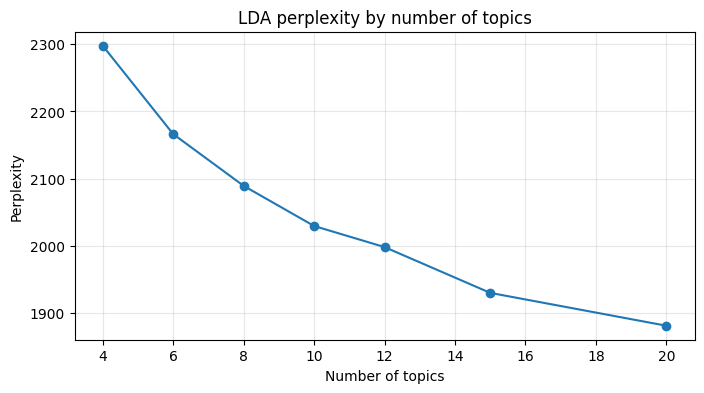

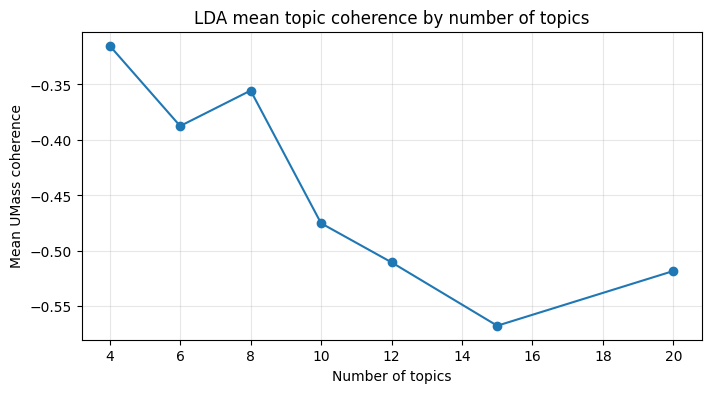

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(evaluation_df["n_topics"], evaluation_df["perplexity"], marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Perplexity")
plt.title("LDA perplexity by number of topics")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(evaluation_df["n_topics"], evaluation_df["mean_umass_coherence"], marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Mean UMass coherence")
plt.title("LDA mean topic coherence by number of topics")
plt.grid(alpha=0.3)
plt.show()


## 8. Inspect all candidate topic summaries

This table helps compare the candidate models qualitatively. The final number of topics should be chosen after reading the top terms and checking whether topics are meaningful for central bank communication.


In [15]:
for k in candidate_k:
    print("=" * 100)
    print(f"LDA with {k} topics")
    summary_k = make_topic_summary(topic_tables[k], n_top_words=15)
    display(summary_k)


LDA with 4 topics


,topic,top_terms
0,0,"inflation, rate, growth, price, monetary, monetary policy, euro, increase, high, term, area, euro area, country, low, fiscal"
1,1,"risk, banking, crisis, capital, institution, stability, european, area, sector, framework, management, regulatory, country, regulation, financial stability"
2,2,"rate, monetary, monetary policy, reserve, price, federal, asset, risk, crisis, term, credit, federal reserve, liquidity, inflation, low"
3,3,"payment, service, sector, development, country, business, growth, banking, industry, investment, global, finance, provide, world, technology"


LDA with 6 topics


,topic,top_terms
0,0,"growth, country, global, investment, sector, increase, high, world, trade, capital, rate, development, international, cent, gdp"
1,1,"risk, banking, capital, institution, management, regulatory, crisis, stability, regulation, financial stability, framework, sector, supervision, supervisory, firm"
2,2,"reserve, rate, asset, credit, liquidity, risk, federal, fund, loan, crisis, exchange, capital, federal reserve, bond, term"
3,3,"payment, service, banking, business, development, sector, provide, technology, industry, money, digital, work, credit, customer, institution"
4,4,"euro, area, monetary, euro area, european, ecb, country, stability, crisis, monetary policy, union, term, fiscal, europe, rate"
5,5,"inflation, rate, price, monetary, monetary policy, growth, increase, target, low, term, high, expectation, rise, demand, change"


LDA with 8 topics


...

,topic,top_terms
0,0,"growth, fiscal, country, public, government, increase, high, debt, gdp, reform, labour, term, productivity, level, investment"
1,1,"risk, capital, banking, crisis, institution, stability, financial stability, management, regulation, regulatory, supervision, framework, supervisory, firm, requirement"
2,2,"reserve, federal, federal reserve, liquidity, rate, asset, fund, security, term, money, balance, participant, fed, financial market, risk"
3,3,"credit, loan, asset, banking, lending, risk, sector, mortgage, debt, capital, business, deposit, increase, high, small"
4,4,"euro, area, euro area, european, ecb, monetary, country, union, stability, europe, crisis, monetary policy, national, term, member"
5,5,"rate, monetary, price, monetary policy, inflation, exchange, exchange rate, low, riksbank, increase, high, country, development, sweden, change"
6,6,"inflation, monetary, monetary policy, rate, price, target, expectation, term, stability, low, inflation target, change, inflation expectation, price stability, long"
7,7,"payment, service, banking, digital, money, technology, industry, customer, islamic, innovation, transaction, provide, business, product, infrastructure"
8,8,"global, country, exchange, international, foreign, capital, growth, domestic, trade, currency, world, crisis, sector, rate, exchange rate"
9,9,"work, climate, change, sector, people, development, business, banker, institution, country, finance, world, challenge, public, opportunity"


LDA with 15 topics


,topic,top_terms
0,0,"growth, fiscal, government, public, debt, increase, gdp, reform, high, country, term, labour, rate, sector, deficit"
1,1,"risk, capital, banking, crisis, stability, institution, financial stability, regulation, regulatory, supervision, management, supervisory, framework, basel, requirement"
2,2,"liquidity, bond, risk, fund, asset, rate, financial market, security, investor, money, term, participant, reserve, money market, hong"
3,3,"credit, loan, asset, risk, lending, mortgage, banking, capital, debt, business, rate, increase, household, deposit, sector"
4,4,"euro, area, euro area, european, ecb, monetary, country, union, stability, europe, national, crisis, monetary policy, member, council"
5,5,"rate, inflation, monetary, monetary policy, price, exchange, exchange rate, riksbank, low, high, increase, target, development, country, sweden"
6,6,"inflation, monetary, monetary policy, rate, price, target, term, expectation, stability, low, long, inflation target, price stability, effect, inflation expectation"
7,7,"federal, reserve, federal reserve, board, percent, community, fed, fomc, committee, program, york, provide, board federal, hold, fund"
8,8,"global, country, exchange, international, foreign, capital, domestic, growth, trade, currency, crisis, world, emerge, exchange rate, rate"
9,9,"work, people, world, country, change, great, think, know, banker, public, research, future, question, come, mean"


LDA with 20 topics


,topic,top_terms
0,0,"fiscal, government, debt, public, country, growth, crisis, reform, gdp, increase, deficit, high, term, budget, level"
1,1,"crisis, stability, risk, financial stability, banking, regulation, sector, capital, institution, financial crisis, global, authority, framework, systemic, macroprudential"
2,2,"board, information, governance, institution, committee, work, reserve, public, member, issue, include, law, act, practice, process"
3,3,"credit, loan, mortgage, lending, rate, banking, household, housing, business, borrower, debt, sector, increase, small, low"
4,4,"euro, area, euro area, european, ecb, monetary, union, country, stability, europe, monetary policy, national, single, member, council"
5,5,"exchange, rate, exchange rate, country, currency, foreign, international, capital, monetary, account, dollar, kong, hong kong, hong, domestic"
6,6,"monetary, monetary policy, inflation, rate, price, target, expectation, stability, term, inflation target, low, change, riksbank, long, price stability"
7,7,"federal, federal reserve, reserve, percent, community, labor, fomc, job, fed, board, work, business, york, program, labor market"
8,8,"global, growth, country, emerge, domestic, trade, sector, world, international, development, south, foreign, region, external, crisis"
9,9,"country, world, people, work, think, come, know, banker, great, mean, change, future, question, problem, public"


## 9. Select the final LDA model

I choose the final number of topics based on a combination of:

1. topic interpretability;
2. limited redundancy across topics;
3. coherence score;
4. comparability with NMF.

The default below is `FINAL_K = 10`, but it should be adjusted after inspecting the topics generated on your machine.


In [16]:
FINAL_K = 10

lda_final = lda_models[FINAL_K]["model"]
doc_topic_final = lda_models[FINAL_K]["doc_topic"]
topic_words_final = lda_models[FINAL_K]["topic_words"]
coherence_final = lda_models[FINAL_K]["coherence"]

topic_summary = make_topic_summary(topic_words_final, n_top_words=15)

display_topics(topic_words_final, FINAL_K)
topic_summary


Topic 0: growth, increase, high, productivity, labour, investment, low, country, gdp, rate, job, employment, change, wage, level, income, rise, cost, work, long
Topic 1: risk, banking, capital, institution, crisis, regulation, regulatory, management, stability, financial stability, supervision, framework, supervisory, firm, requirement, basel, sector, standard, authority, approach
Topic 2: reserve, federal, liquidity, federal reserve, asset, rate, fund, bond, risk, security, term, money, financial market, balance, provide, participant, purchase, sheet, balance sheet, investor
Topic 3: credit, loan, debt, asset, household, rate, mortgage, increase, high, risk, sector, low, lending, capital, business, housing, price, banking, income, borrower
Topic 4: euro, area, euro area, european, monetary, ecb, country, stability, union, crisis, europe, fiscal, monetary policy, term, national, level, member, reform, state, single
Topic 5: price, rate, growth, inflation, increase, continue, percent, d

,topic,top_terms
0,0,"growth, increase, high, productivity, labour, investment, low, country, gdp, rate, job, employment, change, wage, level"
1,1,"risk, banking, capital, institution, crisis, regulation, regulatory, management, stability, financial stability, supervision, framework, supervisory, firm, requirement"
2,2,"reserve, federal, liquidity, federal reserve, asset, rate, fund, bond, risk, security, term, money, financial market, balance, provide"
3,3,"credit, loan, debt, asset, household, rate, mortgage, increase, high, risk, sector, low, lending, capital, business"
4,4,"euro, area, euro area, european, monetary, ecb, country, stability, union, crisis, europe, fiscal, monetary policy, term, national"
5,5,"price, rate, growth, inflation, increase, continue, percent, demand, remain, expect, monetary, term, japan, rise, high"
6,6,"inflation, rate, monetary, monetary policy, price, target, low, expectation, term, change, inflation target, stability, long, high, effect"
7,7,"payment, service, banking, digital, money, technology, customer, islamic, industry, innovation, transaction, provide, consumer, business, product"
8,8,"exchange, country, global, foreign, international, rate, exchange rate, growth, capital, currency, domestic, crisis, world, trade, sector"
9,9,"sector, development, climate, work, institution, business, finance, banker, change, country, people, challenge, public, support, government"


## 10. Manual topic labels

LDA produces topics as word distributions, but it does not name them. The labels below must be filled manually after inspecting the top words and representative speeches.


In [32]:
manual_topic_labels = {
    0: "Growth, productivity and labour markets",
    1: "Banking regulation and financial stability",
    2: "Federal Reserve liquidity and asset purchases",
    3: "Credit, debt and housing markets",
    4: "Euro area and European monetary union",
    5: "Inflation, activity and Japan outlook",
    6: "Inflation targeting and monetary policy framework",
    7: "Payments, digital finance and Islamic finance",
    8: "Global exchange rates and international macro",
    9: "Development, climate and public finance"
}

topic_summary["manual_label"] = topic_summary["topic"].map(manual_topic_labels)
topic_summary = topic_summary.drop(columns=["umass_coherence"], errors="ignore").merge(
    coherence_final, on="topic", how="left"
)
topic_summary



,topic,top_terms,manual_label,umass_coherence
0,0,"growth, increase, high, productivity, labour, investment, low, country, gdp, rate, job, employment, change, wage, level","Growth, productivity and labour markets",-0.404635
1,1,"risk, banking, capital, institution, crisis, regulation, regulatory, management, stability, financial stability, supervision, framework, supervisory, firm, requirement",Banking regulation and financial stability,-0.466520
2,2,"reserve, federal, liquidity, federal reserve, asset, rate, fund, bond, risk, security, term, money, financial market, balance, provide",Federal Reserve liquidity and asset purchases,-0.473872
3,3,"credit, loan, debt, asset, household, rate, mortgage, increase, high, risk, sector, low, lending, capital, business","Credit, debt and housing markets",-0.349184
4,4,"euro, area, euro area, european, monetary, ecb, country, stability, union, crisis, europe, fiscal, monetary policy, term, national",Euro area and European monetary union,-0.404121
5,5,"price, rate, growth, inflation, increase, continue, percent, demand, remain, expect, monetary, term, japan, rise, high","Inflation, activity and Japan outlook",-0.383444
6,6,"inflation, rate, monetary, monetary policy, price, target, low, expectation, term, change, inflation target, stability, long, high, effect",Inflation targeting and monetary policy framework,-0.253409
7,7,"payment, service, banking, digital, money, technology, customer, islamic, industry, innovation, transaction, provide, consumer, business, product","Payments, digital finance and Islamic finance",-1.206464
8,8,"exchange, country, global, foreign, international, rate, exchange rate, growth, capital, currency, domestic, crisis, world, trade, sector",Global exchange rates and international macro,-0.429304
9,9,"sector, development, climate, work, institution, business, finance, banker, change, country, people, challenge, public, support, government","Development, climate and public finance",-0.380115


## 11. Add LDA topic proportions to the dataset

The matrix `doc_topic_final` gives the estimated topic distribution for each document. Each row approximately sums to 1.

For each speech, I add one column per LDA topic, the dominant topic, and the probability of the dominant topic.


In [33]:
row_sums = doc_topic_final.sum(axis=1)
print("Minimum row sum:", row_sums.min())
print("Maximum row sum:", row_sums.max())
print("Mean row sum:", row_sums.mean())


Minimum row sum: 0.9999999999999996
Maximum row sum: 1.0000000000000004
Mean row sum: 1.0


In [34]:
topic_cols = [f"lda_topic_{i}" for i in range(FINAL_K)]

df_lda = df.copy()

for i, col in enumerate(topic_cols):
    df_lda[col] = doc_topic_final[:, i]

df_lda["lda_dominant_topic"] = doc_topic_final.argmax(axis=1)
df_lda["lda_dominant_topic_share"] = doc_topic_final.max(axis=1)
df_lda["lda_dominant_topic_label"] = df_lda["lda_dominant_topic"].map(manual_topic_labels)

df_lda[
    ["doc_id", "year", "macro_period", "central_bank", "lda_dominant_topic", "lda_dominant_topic_share"] + topic_cols[:3]
].head()


,doc_id,year,macro_period,central_bank,lda_dominant_topic,lda_dominant_topic_share,lda_topic_0,lda_topic_1,lda_topic_2
0,0,1997,Pre-GFC,bank of greece,8,0.444605,0.026420,0.000043,0.000043
1,1,1999,Pre-GFC,bank of greece,4,0.676973,0.176817,0.000079,0.000079
2,2,2001,Pre-GFC,bank of greece,4,0.654421,0.046396,0.000076,0.000076
3,3,2002,Pre-GFC,bank of greece,4,0.424471,0.322140,0.000084,0.000084
4,4,2002,Pre-GFC,bank of greece,4,0.387950,0.062508,0.253883,0.092792


## 12. Dominant topic distribution

This plot shows how many speeches are assigned to each dominant LDA topic.


In [35]:
dominant_topic_counts = (
    df_lda["lda_dominant_topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dominant_topic_counts.columns = ["topic", "n_speeches"]
dominant_topic_counts["manual_label"] = dominant_topic_counts["topic"].map(manual_topic_labels)

dominant_topic_counts


,topic,n_speeches,manual_label
0,0,1119,"Growth, productivity and labour markets"
1,1,2750,Banking regulation and financial stability
2,2,852,Federal Reserve liquidity and asset purchases
3,3,935,"Credit, debt and housing markets"
4,4,2488,Euro area and European monetary union
5,5,2000,"Inflation, activity and Japan outlook"
6,6,1956,Inflation targeting and monetary policy framework
7,7,1733,"Payments, digital finance and Islamic finance"
8,8,1989,Global exchange rates and international macro
9,9,3100,"Development, climate and public finance"


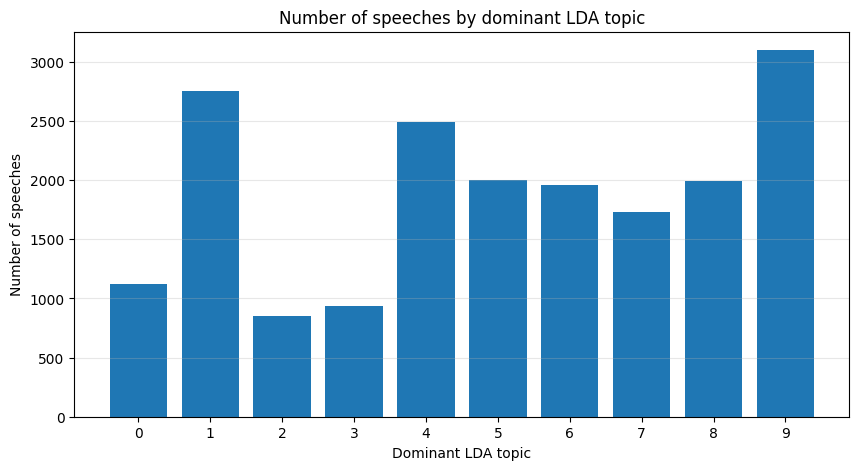

In [36]:

plt.figure(figsize=(10, 5))
plt.bar(dominant_topic_counts["topic"].astype(str), dominant_topic_counts["n_speeches"])
plt.xlabel("Dominant LDA topic")
plt.ylabel("Number of speeches")
plt.title("Number of speeches by dominant LDA topic")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 13. Topic prevalence over time

I compute the average topic proportion by year. This is better than counting documents because the number of speeches varies across years.


In [37]:
topic_by_year = (
    df_lda
    .groupby("year")[topic_cols]
    .mean()
    .reset_index()
)

topic_by_year.head()


,year,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,lda_topic_7,lda_topic_8,lda_topic_9
0,1997,0.112240,0.136032,0.065944,0.036581,0.107898,0.130598,0.139599,0.057812,0.164572,0.048725
1,1998,0.068577,0.154894,0.063563,0.049485,0.122844,0.103518,0.118673,0.055023,0.219474,0.043947
2,1999,0.082890,0.136904,0.069494,0.040253,0.180764,0.096230,0.137982,0.043517,0.163617,0.048350
3,2000,0.125835,0.114126,0.040956,0.034915,0.154726,0.118982,0.154840,0.058885,0.137066,0.059670
4,2001,0.111873,0.123513,0.056407,0.043169,0.154367,0.130726,0.150150,0.058324,0.116945,0.054525


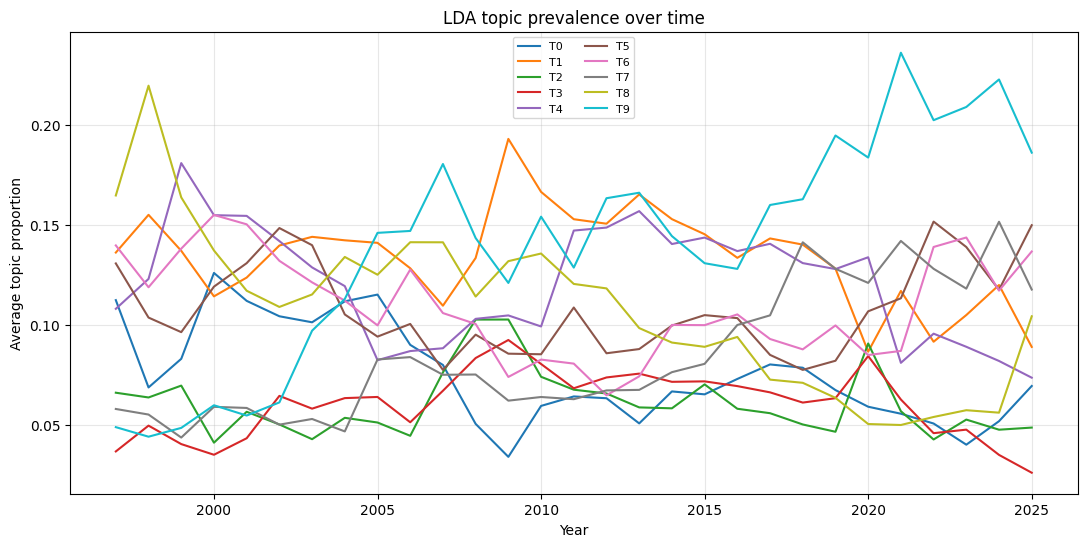

In [38]:

plt.figure(figsize=(13, 6))

for i, col in enumerate(topic_cols):
    plt.plot(topic_by_year["year"], topic_by_year[col], label=f"T{i}")

plt.xlabel("Year")
plt.ylabel("Average topic proportion")
plt.title("LDA topic prevalence over time")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.show()


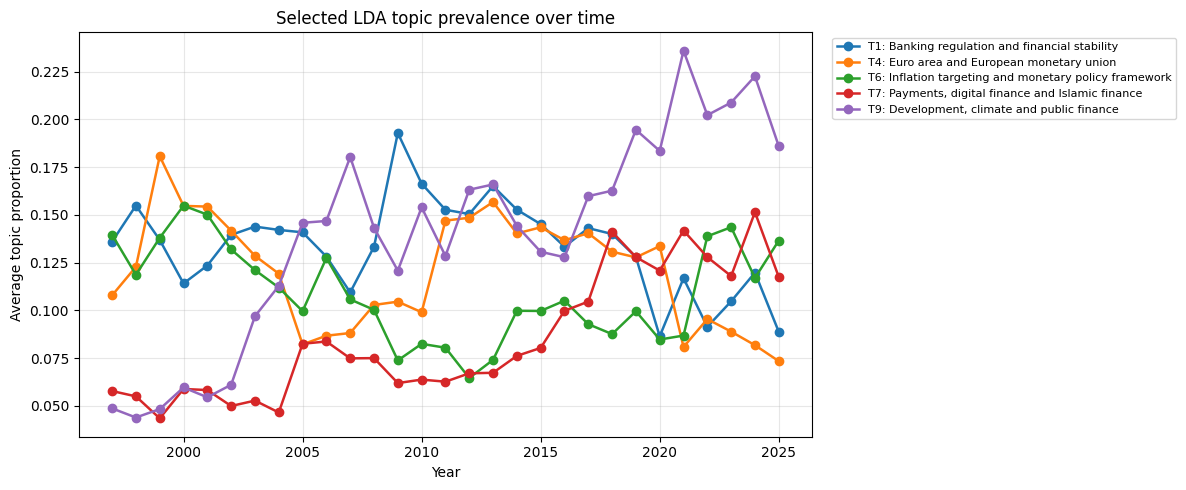

In [47]:
selected_lda_topics = [1, 4, 6, 7, 9]

plt.figure(figsize=(12, 5))

for topic_id in selected_lda_topics:
    col = f"lda_topic_{topic_id}"
    label = f"T{topic_id}: {manual_topic_labels[topic_id]}"
    plt.plot(topic_by_year["year"], topic_by_year[col], marker="o", linewidth=1.8, label=label)

plt.xlabel("Year")
plt.ylabel("Average topic proportion")
plt.title("Selected LDA topic prevalence over time")
plt.grid(alpha=0.3)
plt.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 14. Topic prevalence by macro-financial period

This heatmap connects the topics to broad macro-financial regimes.


In [39]:
period_order = [
    "Pre-GFC",
    "Global Financial Crisis",
    "Euro crisis / post-GFC",
    "Low rates / QE",
    "Covid",
    "Inflation tightening"
]

topic_by_period = (
    df_lda
    .groupby("macro_period")[topic_cols]
    .mean()
    .reindex(period_order)
)

topic_by_period


,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,lda_topic_7,lda_topic_8,lda_topic_9
macro_period,,,,,,,,,,
Pre-GFC,0.103284,0.135680,0.051726,0.053082,0.120081,0.113471,0.125618,0.062648,0.137057,0.097352
Global Financial Crisis,0.054693,0.145038,0.093764,0.080832,0.098569,0.085991,0.093394,0.070691,0.128863,0.148166
Euro crisis / post-GFC,0.060564,0.157661,0.064655,0.073818,0.138520,0.093297,0.080289,0.067401,0.112475,0.151320
Low rates / QE,0.072837,0.137835,0.055623,0.066017,0.135599,0.089678,0.096697,0.111837,0.077054,0.156822
Covid,0.057222,0.101339,0.073970,0.073629,0.107825,0.109841,0.085792,0.131131,0.050047,0.209205
Inflation tightening,0.047764,0.104826,0.047535,0.042454,0.088513,0.136419,0.133429,0.131871,0.056629,0.210559


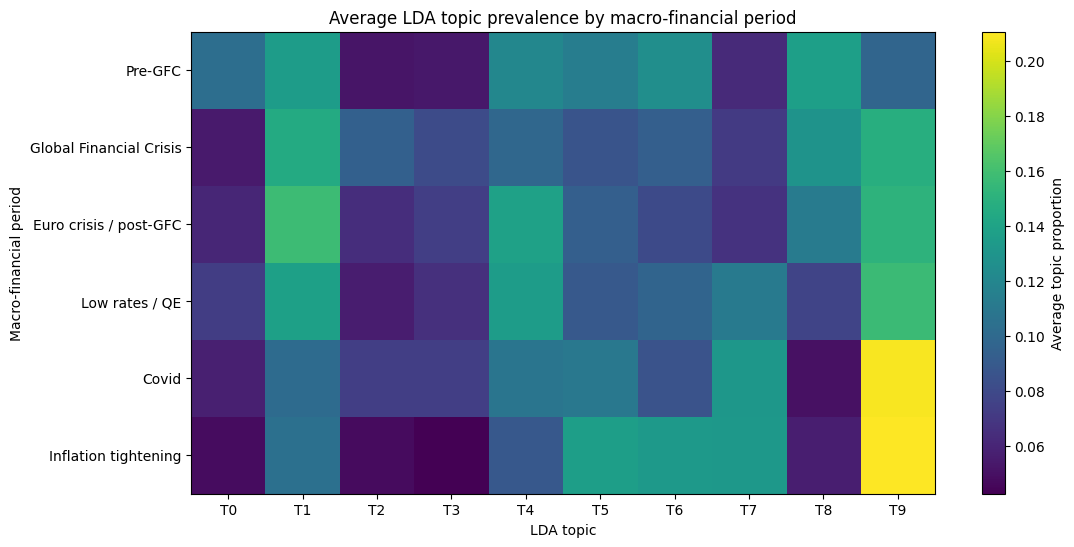

In [40]:
plt.figure(figsize=(12, 6))
plt.imshow(topic_by_period.values, aspect="auto")
plt.colorbar(label="Average topic proportion")
plt.xticks(range(FINAL_K), [f"T{i}" for i in range(FINAL_K)])
plt.yticks(range(len(topic_by_period.index)), topic_by_period.index)
plt.xlabel("LDA topic")
plt.ylabel("Macro-financial period")
plt.title("Average LDA topic prevalence by macro-financial period")
plt.show()


## 15. Representative speeches

Top words alone are not always sufficient to interpret a topic. I inspect representative speeches, i.e. speeches with the highest probability for a given topic.


In [41]:
def show_representative_speeches(df, topic_id, n=5, text_col="raw_text_stripped"):
    topic_col = f"lda_topic_{topic_id}"

    cols = [
        "description",
        "central_bank",
        "year",
        "macro_period",
        topic_col,
        text_col
    ]

    return (
        df.sort_values(topic_col, ascending=False)
        [cols]
        .head(n)
    )


show_representative_speeches(df_lda, topic_id=0, n=3)


,description,central_bank,year,macro_period,lda_topic_0,raw_text_stripped
5106,"Testimony of Mr Alan Greenspan, Chairman of the Board of Governors of the US Federal Reserve System, before the Special Committee on Aging, U.S. Senate, Washington, D.C., 27 Fe...",board of governors of the federal reserve system,2003,Pre-GFC,0.979285,"Alan Greenspan: Aging global population Testimony of Mr Alan Greenspan, Chairman of the Board of Governors of the US Federal Reserve System, before the Special Committee on Agi..."
4032,"Main points of remarks by Dr Karnit Flug, Governor of the Bank of Israel, at the conference on raising the retirement age for women, Jerusalem, 1 July 2015.",bank of israel,2015,Low rates / QE,0.978815,"Karnit Flug: Raising the retirement age for women in Israel Main points of remarks by Dr Karnit Flug, Governor of the Bank of Israel, at the conference on raising the retiremen..."
5221,"Opening remarks by Mr Alan Greenspan, Chairman of the Board of Governors of the US Federal Reserve System, at a symposium sponsored by the Federal Reserve Bank of Kansas City, ...",board of governors of the federal reserve system,2004,Pre-GFC,0.960837,"Alan Greenspan: Economic implications of population aging Opening remarks by Mr Alan Greenspan, Chairman of the Board of Governors of the US Federal Reserve System, at a sympos..."


In [42]:
for topic_id in range(FINAL_K):
    topic_col = f"lda_topic_{topic_id}"
    top_row = df_lda.sort_values(topic_col, ascending=False).iloc[0]

    print("=" * 100)
    print(f"Topic {topic_id}")
    print("Top terms:", topic_summary.loc[topic_summary["topic"] == topic_id, "top_terms"].values[0])
    print("Most representative speech:")
    print("Year:", top_row["year"])
    print("Central bank:", top_row["central_bank"])
    print("Macro period:", top_row["macro_period"])
    print("Description:", top_row["description"])
    print("Topic probability:", round(top_row[topic_col], 4))


Topic 0
Top terms: growth, increase, high, productivity, labour, investment, low, country, gdp, rate, job, employment, change, wage, level
Most representative speech:
Year: 2003
Central bank: board of governors of the federal reserve system
Macro period: Pre-GFC
Description: Testimony of Mr Alan Greenspan, Chairman of the Board of Governors of the US Federal Reserve System, before the Special Committee on Aging, U.S. Senate, Washington, D.C., 27 February 2003.
Topic probability: 0.9793
Topic 1
Top terms: risk, banking, capital, institution, crisis, regulation, regulatory, management, stability, financial stability, supervision, framework, supervisory, firm, requirement
Most representative speech:
Year: 2005
Central bank: board of governors of the federal reserve system
Macro period: Pre-GFC
Description: Remarks by Ms Susan Schmidt Bies, Member of the Board of Governors of the US Federal Reserve System, at the Risk USA 2005 Congress, Boston, 8 June 2005.
Topic probability: 0.9994
Topic 

## 16. Top central banks by topic

This diagnostic checks whether some topics are dominated by a small number of central banks. This matters because the corpus is institutionally imbalanced.


In [43]:
topic_bank_rows = []

for topic_id in range(FINAL_K):
    topic_col = f"lda_topic_{topic_id}"

    tmp = (
        df_lda
        .groupby("central_bank")[topic_col]
        .mean()
        .sort_values(ascending=False)
        .head(5)
        .reset_index()
    )

    tmp["topic"] = topic_id
    tmp = tmp.rename(columns={topic_col: "mean_topic_proportion"})
    topic_bank_rows.append(tmp)

topic_bank_summary = pd.concat(topic_bank_rows, ignore_index=True)
topic_bank_summary[["topic", "central_bank", "mean_topic_proportion"]].head(20)


,topic,central_bank,mean_topic_proportion
0,0,federal reserve bank of richmond,0.559258
1,0,bank of israel,0.325542
2,0,federal reserve bank of dallas,0.225943
3,0,bank of poland,0.198005
4,0,central bank of malta,0.182653
5,1,central bank of uruguay,0.836487
6,1,central bank of belize,0.510710
7,1,central bank of bolivia,0.481109
8,1,bank for international settlements,0.455676
9,1,central bank of kuwait,0.321027


## 17. Optional comparison with NMF outputs

If the NMF notebook has already been run and the file `bis_speeches_with_nmf_topics.csv` is available, this cell loads it and prepares the dataset for later comparison.


In [44]:
if os.path.exists("bis_speeches_with_nmf_topics.csv"):
    df_nmf = pd.read_csv("bis_speeches_with_nmf_topics.csv")
    print("NMF dataset found:", df_nmf.shape)
else:
    print("NMF dataset not found in the current directory. This is not a problem for the LDA notebook.")


NMF dataset not found in the current directory. This is not a problem for the LDA notebook.


## 18. Save LDA outputs

The following files are saved:

- `bis_speeches_with_lda_topics.csv`: full dataset with LDA topic proportions;
- `lda_topic_summary.csv`: one row per topic with top words and manual labels;
- `lda_topic_top_words_long.csv`: long-format topic-word table;
- `lda_model_evaluation.csv`: metrics for different values of K;
- `lda_topic_by_year.csv`: topic prevalence by year;
- `lda_topic_by_period.csv`: topic prevalence by macro-financial period.

In Google Colab, these files are saved in `/content/` unless another path is specified.


In [45]:
df_lda.to_csv("bis_speeches_with_lda_topics.csv", index=False)
topic_summary.to_csv("lda_topic_summary.csv", index=False)
topic_words_final.to_csv("lda_topic_top_words_long.csv", index=False)
evaluation_df.to_csv("lda_model_evaluation.csv", index=False)
topic_by_year.to_csv("lda_topic_by_year.csv", index=False)
topic_by_period.to_csv("lda_topic_by_period.csv")

print("Saved: bis_speeches_with_lda_topics.csv")
print("Saved: lda_topic_summary.csv")
print("Saved: lda_topic_top_words_long.csv")
print("Saved: lda_model_evaluation.csv")
print("Saved: lda_topic_by_year.csv")
print("Saved: lda_topic_by_period.csv")
print("Final dataset shape:", df_lda.shape)


Saved: bis_speeches_with_lda_topics.csv
Saved: lda_topic_summary.csv
Saved: lda_topic_top_words_long.csv
Saved: lda_model_evaluation.csv
Saved: lda_topic_by_year.csv
Saved: lda_topic_by_period.csv
Final dataset shape: (18922, 25)


In [46]:
# If you are using Google Colab and want to download the output files, uncomment this cell.
# from google.colab import files

# files.download("bis_speeches_with_lda_topics.csv")
# files.download("lda_topic_summary.csv")
# files.download("lda_topic_top_words_long.csv")
# files.download("lda_model_evaluation.csv")
# files.download("lda_topic_by_year.csv")
# files.download("lda_topic_by_period.csv")


## 19. What to inspect before moving to BERTopic

Before moving to the next notebook, inspect:

1. the topics for each candidate number of topics;
2. the final `topic_summary`;
3. the dominant topic distribution;
4. the topic prevalence over time;
5. the heatmap by macro-financial period;
6. representative speeches for each topic.

The final labels should be updated manually after this inspection.
